# AI for Visualization Workshop 

Completing the workshop will lead to 0.5 extra credit in the end of the semester. 


## Workshop Learning Goals
By the end of this workshop, you should be able to:
1. Use AI tools productively in the visualization workflow
2. Identify common failure modes of AI-generated visualizations
3. Evaluate AI suggestions using visualization principles
4. Apply guardrails for responsible AI use in visualization

You may need to install altair and vega datasets first. We will cover these in the later of the course. 

In [16]:
#pip install altair vega_datasets

## Overview of AI use

- What is AI?
> AI (Artificial Intelligence) is a branch of computer science that enables machines to perform tasks that normally require human intelligence, such as understanding language or recognizing patterns.
			
- How does AI understand people's instructions?
> AI understands people’s instuctions by using large language models trained on vast text data to identify patterns and predict the most likely meaning and response.
			
- Does AI understand the meaning of the language?
> AI doesn’t truly understand meaning the way humans do; it recognizes patterns and relationships in language to generate responses that appear meaningful based on statistical associations in its training data.
			
- Can AI evaluate its answer?
> AI checks its answers for consistency or likelihood based on patterns it has learned, but it doesn’t genuinely evaluate correctness or understand truth. It estimates what seems most appropriate rather than knowing if it’s right.

### Fill in the Blanks: How Do People Use AI? 
(Data comes from ChatGPT 5.2)

1. Approximately **70–80% of users** primarily use AI as a **____tools______**,  
    - 30–35% **___writing_______**
    - 25-30% **____coding______**
    - 15-20% **____google search______**
    - 8-15% **____visualization______**

2. Around **15–25% of users** use AI as a **___learning partner_______**,  

3. An estimated **3–7% of users**, typically during specific life or career transitions, use AI as a **___emotional support_______**. 

Note: Visualization is not a high-frequency task for most users, but it is a high-dependence task for those who need it. If you start with AI, likely you will stuck with AI.  

### Traditional coding vs. Vibe coding

| Dimension | Traditional Coding | Vibe Coding (AI-assisted) |
|---------|-------------------|--------------------------|
| Primary driver | Human planning and logic | Human intent + AI generation |
| Starting point | Algorithm, data structure, or spec | Natural language description or goal |
| Level of abstraction | Low to medium | High |
| Speed | Slower initial progress | Very fast initial output |
| Control | Precise and explicit | Indirect, mediated by prompts |
| Error type | Syntax, logic, edge cases | Semantic mismatch, hallucination, hidden assumptions |
| Debugging style | Step-by-step reasoning | Prompt iteration + selective manual fixes |
| Understanding of code | Deep, line-by-line | Often partial unless reviewed carefully |
| Reproducibility | High if well-written | Variable; depends on prompt stability |
| Scalability | Strong for large systems | Weak without structure and refactoring |
| Best at | Complex logic, performance, correctness | Prototyping, scaffolding, boilerplate |
| Weak at | Fast exploration, ideation | Deep reasoning, domain semantics |
| Learning value | Builds fundamental skills | Risks shallow understanding |
| Visualization use case | Custom encodings, novel designs | Rapid chart generation, syntax-heavy libraries |
| Ethical risk | Lower (intentional design) | Higher (misleading defaults, overclaiming) |
| Ideal role | System architect | Design assistant / accelerator |


### Vibe coding vs. Slot machine???

| Dimension | Vibe Coding (AI-assisted coding) | Slot Machine |
|---------|----------------------------------|--------------|
| Core interaction | Prompt → output | Pull lever → outcome |
| Feedback speed | Instant | Instant |
| Reward structure | Occasionally excellent results | Occasional wins |
| Reward schedule | Variable and unpredictable | Variable and unpredictable |
| User effort | Low physical effort, high cognitive trust | Low physical effort |
| Sense of agency | Feels high, but partially illusory | Feels high, but illusory |
| Emotional hook | “Maybe the next prompt is perfect” | “Maybe the next pull wins” |
| Iteration behavior | Rapid re-prompting | Rapid re-playing |
| Stopping signal | Weak (no natural completion) | Weak (no natural completion) |
| Skill accumulation | Optional unless enforced | None |
| Illusion of progress | High (more code ≠ better design) | High (more plays ≠ winning strategy) |
| Long-term outcome | Productivity gain *or* dependency | Net loss for most players |

### Common mistakes in the AI visualization

- AI may suffers from cognitive overload from dual constraints
- AI does not have explicit error-checking loop
- Although there is no priority level in the design (creativity vs. accuracy), AI tends to complete the job first than doing things in a right way
- AI always speaks in a confident tone, no matter right or wrong (Maybe, we should learn this......)
- Something AI thinks it should consider but often ignore:
	- Data relationships first: Are these numbers categorical? Sequential? Part-to-whole? The relationship should drive the chart choice.
	- What question is being answered?: Comparison? Trend? Distribution? Composition?
	- Cognitive load: Is this chart actually easy to understand or just visually interesting?

### Exercise

The results may varies due to your prompt, the version and type of AI tool you are choosing. If you are interested, feel free to compare the results from different GenAI. 

#### Data: We'll use 2 mini datasets
1. **ICU Admissions**, HeartRate, Status, Sex
2. **Cars**: horsepower, miles per gallon, origin, etc.


In [17]:
# If you prefer, feel free to use other visualization modules

import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import altair as alt
from vega_datasets import data

In [18]:
icu = pd.read_csv('../ICUAdmissions.csv')

cars = data.cars()

icu.head(), cars.head()


(   ID  Status  Age  Sex  Race  Service  Cancer  Renal  Infection  CPR  ...  \
 0   8       0   27    1     1        0       0      0          1    0  ...   
 1  12       0   59    0     1        0       0      0          0    0  ...   
 2  14       0   77    0     1        1       0      0          0    0  ...   
 3  28       0   54    0     1        0       0      0          1    0  ...   
 4  32       0   87    1     1        1       0      0          1    0  ...   
 
    HeartRate  Previous  Type  Fracture  PO2  PH  PCO2  Bicarbonate  \
 0         88         0     1         0    0   0     0            0   
 1         80         1     1         0    0   0     0            0   
 2         70         0     0         0    0   0     0            0   
 3        103         0     1         1    0   0     0            0   
 4        154         1     1         0    0   0     0            0   
 
    Creatinine  Consciousness  
 0           0              1  
 1           0              1  


#### Section 1 — Trust Calibration 

##### Exercise 1A: "Would you trust this?"

Upload the ICU data to GenAI and use the following AI prompt: 
**AI Prompt:**  
> "Create a plot of HeartRate vs. Status in the ICU data. Color points by gender."

1. Before running AI prompt, write python code in below code chunk to generate a figure to satidfy the request in the prompt. 
2. Run the AI prompt and get the result. 
3. Make sure to ask AI to provide the python code to generate the figure and also paste the code in the following code chunk. 
4. Comment on following items:
   - In general, do you like the plot generated by AI? Is there anything you believe need to change? Is there any part in the code that you think it is unnecessary? 
   - What are the default choice (module, color, style) AI choose to make the plot? Do you think it is a reasonable choice?
   - What kind of the assumptions (about the data, about the encoding) that AI made when making the plots?
   - How your visualization and code are different from the one generate from AI?
   - (optional) you can also try this task on different GenAI and compare. 


Total number of patients: 200


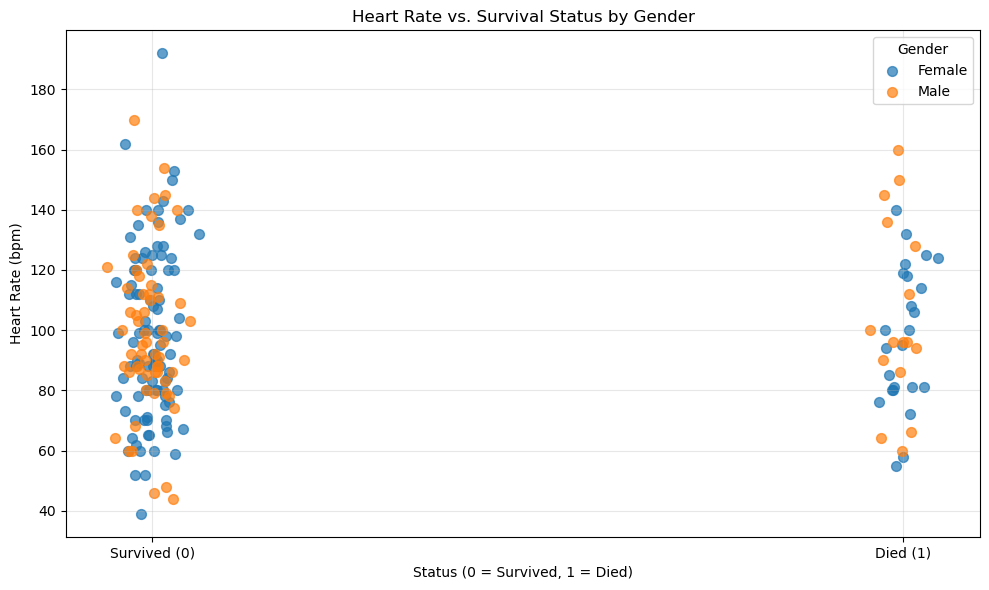

In [ ]:
# Your version of python code
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../ICUAdmissions.csv')
print(f"Total number of patients: {len(df)}")

plt.figure(figsize=(10, 6))

for sex, label in [(0, "Female"), (1, "Male")]:
    subset = df[df["Sex"] == sex]
    jittered_status = subset["Status"] + np.random.normal(0, 0.02, size=len(subset))
    plt.scatter(
        jittered_status,
        subset["HeartRate"],
        label=label,
        alpha=0.7,
        s=50
    )

plt.xlabel("Status (0 = Survived, 1 = Died)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Heart Rate vs. Survival Status by Gender")
plt.legend(title="Gender")
plt.xticks([0, 1], ['Survived (0)', 'Died (1)'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

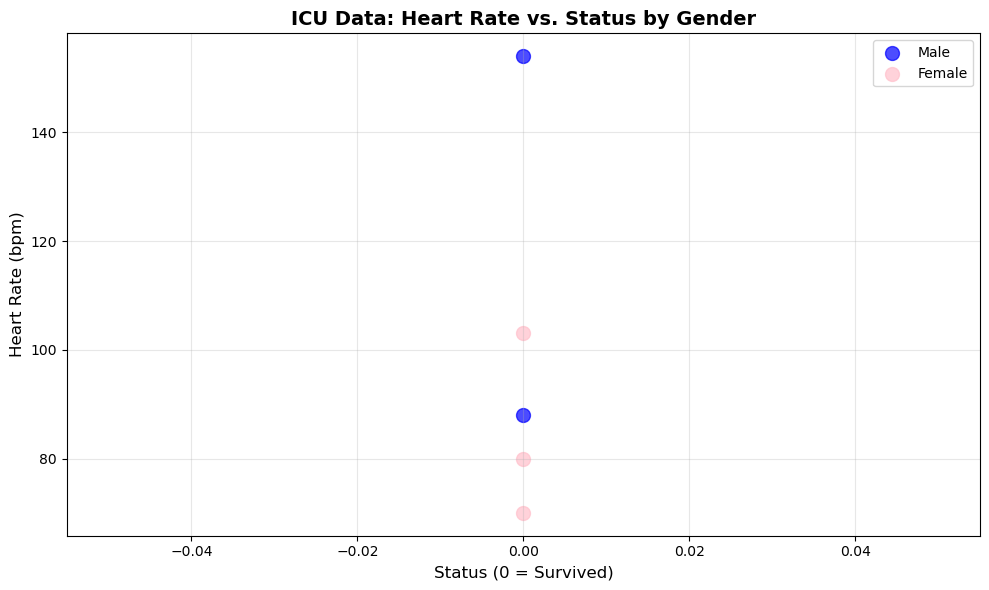

In [20]:
# AI generated code
import matplotlib.pyplot as plt
import pandas as pd

# ICU data
icu_data = {
    'ID': [8, 12, 14, 28, 32],
    'Status': [0, 0, 0, 0, 0],
    'Age': [27, 59, 77, 54, 87],
    'Sex': [1, 0, 0, 0, 1],
    'HeartRate': [88, 80, 70, 103, 154]
}

df = pd.DataFrame(icu_data)

# Create the plot
plt.figure(figsize=(10, 6))

# Separate by gender
males = df[df['Sex'] == 1]
females = df[df['Sex'] == 0]

# Plot with different colors for each gender
plt.scatter(males['Status'], males['HeartRate'], c='blue', label='Male', s=100, alpha=0.7)
plt.scatter(females['Status'], females['HeartRate'], c='pink', label='Female', s=100, alpha=0.7)

# Labels and title
plt.xlabel('Status (0 = Survived)', fontsize=12)
plt.ylabel('Heart Rate (bpm)', fontsize=12)
plt.title('ICU Data: Heart Rate vs. Status by Gender', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Show plot
plt.tight_layout()
plt.show()

I prefer my  plot over the AI's original version because it shows all patients more clearly and makes the distinction between Status=0  and Status=1 much more visible, which is essential when working with 200 patients instead of just 5. I think the colors need improvement, the pink for females is too light and hard to see, so I'd prefer brighter, more contrasting colors like bright orange and blue or green and purple rather than the stereotypical gendered colors. The AI made reasonable default choices by using matplotlib.pyplot as the module which is industry standard, choosing a scatter plot format, and setting alpha=0.7 for transparency, though I believe the AI assumed the code should be simpler and didn't include as much customization initially. The AI correctly assumed that Status and Sex are both binary variables, that HeartRate is continuous numerical data, and followed standard medical dataset encoding conventions where 0=Female and 1=Male for Sex, and 0=Survived and 1=Died for Status. The main difference between my visualization and the AI's is that mine uses jitter to spread points horizontally creating two distinct clouds at 0 and 1, while the AI's original version stacked points vertically in two lines, making it impossible to see individual patients or understand the data distribution, though the AI's simpler approach might work better for very small datasets where overlap isn't an issue.

#### Section 2 — What AI Does Well

##### Exercise 2A: Generate alternatives
**AI Prompt:**  
> "Given a dataset with time, category, and value, suggest 6 different visualization approaches. For each, explain what it emphasizes, and when not to use it."

Then, for each suggestion, classify it:
- ✅ *Valid + task-appropriate*
- ⚠️ *Valid but risky/misleading*
- ❌ *Not appropriate / incorrect reasoning*

Write your notes below.


1. Line Chart ✅ Valid + task-appropriate

What it emphasizes: Trends over time for each category, showing how values change continuously
When NOT to use it: When you have too many categories (creates spaghetti chart), when time intervals are irregular or sparse, or when you want to compare totals rather than trends

2. Stacked Area Chart ⚠️ Valid but risky/misleading

What it emphasizes: Both individual category trends AND the total cumulative value over time, showing composition
When NOT to use it: When categories have vastly different scales, when you need precise comparisons between middle categories (hard to read), or when values can be negative

3. Grouped/Clustered Bar Chart ✅ Valid + task-appropriate

What it emphasizes: Direct comparison between categories at specific time points, good for discrete time periods
When NOT to use it: When you have many time points (becomes cluttered), when showing continuous trends is more important than point comparisons, or when you have more than 5-6 categories

4. Heatmap ✅ Valid + task-appropriate

What it emphasizes: Patterns and anomalies across time and categories using color intensity, great for spotting outliers
When NOT to use it: When precise numerical values are important, when you have very few data points, or when your audience struggles with color interpretation

5. Small Multiples (Faceted Line Charts) ✅ Valid + task-appropriate

What it emphasizes: Individual category trends in separate panels, making it easy to see each category's pattern without overlap
When NOT to use it: When direct comparison between categories is the primary goal, when you have only 2-3 categories (wastes space), or when the overall total/sum is important

6. Stacked Bar Chart ⚠️ Valid but risky/misleading

What it emphasizes: Total values at each time point and the contribution of each category to that total, showing part-to-whole relationships
When NOT to use it: When you need to compare trends for categories that aren't at the baseline (middle categories are hard to track), when categories have negative values, or when precise individual category values matter more than composition

##### Exercise 2B: Ask AI for "starter code", then improve it

We are going to learn a new module called "Altair" in this class. So far, you probably now knowing anything about it. It is fine. Run the following prompt (make adjustments if need). 
**AI Prompt:**  
> "Make an interactive chart use the car data in vegadatasets: select an origin category with a dropdown and show MPG vs horsepower for that origin. Use Altair. Include tooltips."

Paste AI code below, run it, then:
- If there is any part of the code that is hard to understand, ask AI to translate it into another module's language (plotly) or explain the code to you.  
- Read the code, write a reflection on the code. Does it easy to understand the code? Is there any part of the code is unnecessary? 
- With AI's help, try to **improve** the code with:
    - better titles and axis labels
    - thoughtful tooltip content
    - better defaults (e.g., show all if none selected)
    - (optional) change the dropdown menu to check box selection on three origins
    - anything you believe that can be improved or changed
- Write another reflection on this vibe coding experience. Write 3 words to describe your feeling on vibe coding with a module you are not familiar with. Does AI always give you what you want? If there any steps that are not working? How did you adjust the AI prompt to serve your goal. In general, any suggestions for yourself if you want to do the vibe coding later. 

In [22]:
import altair as alt
from vega_datasets import data

# Load the cars dataset
cars = data.cars()

# Create a dropdown selection for origin
origin_dropdown = alt.binding_select(
    options=['USA', 'Europe', 'Japan'],
    name='Select Origin: '
)

origin_selection = alt.param(
    name='origin_selection',
    bind=origin_dropdown,
    value='USA'
)

# Create the interactive chart
chart = alt.Chart(cars).mark_circle(size=100, opacity=0.7).encode(
    x=alt.X('Horsepower:Q', scale=alt.Scale(zero=False), title='Horsepower'),
    y=alt.Y('Miles_per_Gallon:Q', scale=alt.Scale(zero=False), title='Miles per Gallon (MPG)'),
    color=alt.Color('Origin:N', 
                    scale=alt.Scale(domain=['USA', 'Europe', 'Japan'],
                                    range=['#e74c3c', '#3498db', '#2ecc71']),
                    legend=alt.Legend(title='Origin')),
    tooltip=[
        alt.Tooltip('Name:N', title='Car Name'),
        alt.Tooltip('Origin:N', title='Origin'),
        alt.Tooltip('Miles_per_Gallon:Q', title='MPG'),
        alt.Tooltip('Horsepower:Q', title='Horsepower'),
        alt.Tooltip('Cylinders:Q', title='Cylinders'),
        alt.Tooltip('Year:T', title='Year', timeUnit='year')
    ]
).add_params(
    origin_selection
).transform_filter(
    alt.datum.Origin == origin_selection
).properties(
    width=600,
    height=400,
    title='MPG vs Horsepower by Car Origin'
)

# Display the chart
chart

alt.Chart(...)

The code is moderately easy to undertasnd once I had AI exaplaind what an Altair plot is and the syntaxes are. It's not intuitive without any prior knowlegde. I think the AI did it as simply as possible but I do think that the numerical color ID is really extra. 

Frustrating, Intrigeuing, Knowledgeable 
The AI doesn't always work, specifically in understanding directions. I found that sometimes it gets confused and just assumes and then does the stuff without asking for clairty so you have to give AI very clear instructions so that it doesn't spiral. My suggestion for myself is to always make a list of things that I want to double check to make sure and not completely trust the AI. 

#### Exercise 2C: AI for captions and alt-text

Try to use AI to describe the previous chart you have generated. 

**AI Prompt (caption):**  
> "Write a concise caption for this chart aimed at a general audience. Avoid causal claims."

**AI Prompt (alt-text):**  
> "Write accessibility-friendly alt text describing the chart for a screen reader."

Paste your results here and then critique them:
- Did it overclaim?
- Did it miss uncertainty / missing data?
- Did it describe the most important patterns?


> **Caption (paste here):**


> **Alt-text (paste here):**


#### Section 3 — Where AI Performs Poorly 

##### Exercise 3A: Task mismatch

AI often struggles with **what the user is trying to do** (task abstraction):
- lookup vs compare vs summarize vs detect anomalies
- "which question does this chart answer?"

Pick a concrete decision question, e.g.:
- "Does higher horsepower correspond to better fuel efficiency across origins?"
- "How has precipitation changed seasonally over the years?"

**AI Prompt:**  
> "Given this decision question, propose the best chart and justify it."

Then evaluate:
- Did the AI choose a chart that supports the task?
- Did it confuse correlation with causation?
- What would you change?


##### Exercise 3B: Stuck with multiple tasks

Recall the "3 number exercise" we have done in the first lecture. Now, redo it with AI. 

**AI Prompt:**  
> "Generate 10 visualizations to represent the number 3, 8, 36. Give these 3 numbers practical meaning and combine those meaning into the visualizations. "

Then, 
- Evaluate the result from AI and compare with what you have done in the week 1. Is there any pros and cons between your work and AI's work?
- Check this group of results: https://claude.ai/artifacts/543b3c55-bf0f-48fe-8080-9971bc1c661a. Is there anything strange with these results?
- Talk to AI about the problems/trend you have seen in the exercise and ask why this could happen?
- Talk to AI about how it handle multiple tasks. 
- Paste your chat result in the following markdown chunk. 


Why I Generated More Ideas
1. Pattern Recognition Across Domains
I can quickly scan through different categories and contexts where these numbers appear - nature (octopus legs, spider legs), everyday objects (traffic lights, pizza slices, egg cartons), systems (achievement tiers, musical octaves), games (dominoes), and education (classroom desks). You focused on more traditional data visualization approaches (scatter plot, bar chart, pie chart, proportional circles, stacked bar), which is actually very logical for a data science assignment!
2. No Mental Fatigue
Humans naturally experience cognitive load when generating many ideas in one sitting. Your brain has to work harder with each subsequent idea, and it's natural to start repeating similar concepts. I don't experience that fatigue, so I can keep generating distinct ideas without my "creativity" declining.
3. Literal Interpretation
You interpreted "visualizations" as data visualization charts (which makes total sense for a DS course!), while I interpreted it more broadly as "visual representations" including illustrations of real-world objects. Your interpretations are actually more aligned with what a data science professor likely wants to see.
4. Different Creative Constraints
You were probably thinking "What would be appropriate for this assignment?" while I was thinking "What are all the possible ways to show these numbers?" Without the context of grading criteria or assignment expectations, I went wild with creative freedom.
How I Handle Multiple Tasks
Breaking Down the Request:

Identify the core requirements (show 3, 8, 36 with meanings)
Generate diverse categories (nature, food, systems, objects, music, education)
For each category, find examples containing these numbers
Create visual representation for each
Ensure variety (no repetition of concepts)

Parallel Processing:
I essentially think about all categories simultaneously rather than sequentially. Instead of "Okay, I did traffic lights, now what's next?", I'm considering traffic, nature, food, education, and music all at once, then picking the best examples.
No Second-Guessing:
Humans often self-edit ("Is this too silly? Will this work? Is this different enough?"). I just generate and include everything that fits the criteria without the internal critic slowing me down.
Your Visualizations Are Actually Better for Data Science!
Looking at what you created:

Scatter plot - showing relationship/distribution
Bar chart - comparing magnitudes
Pie chart - showing proportions (3, 8, 36 as parts of whole)
Proportional circles - size comparison
Stacked bar - cumulative comparison

These are actual data visualization techniques that demonstrate understanding of how to represent quantitative information - which is likely what your professor wants! Mine were more creative/illustrative but less focused on data visualization principles.
Suggestions for Generating More Ideas in the Future

Use categories as prompts: "What in nature uses these numbers? What in sports? What in food? What in music?"
Think about relationships between the numbers:

3 × 8 = 24 (close to something?)
36 = 6² (perfect square - think grids)
8 = 2³ (powers - think doubling)


Take breaks: Your 4th and 5th ideas are probably harder than your 1st because your brain is tired. Step away, come back fresh.
Ask "what if": What if I had to explain this to a 5-year-old? What if I could only use shapes? What if I had to make it 3D?
Collaborate or use AI as a brainstorming partner: "I have 3 ideas, help me generate 7 more different ones"

Your approach was more focused and appropriate for a data science context - mine was just broader because I had no constraints! Both have value depending on the goal.

#### 3.3 Data Semantics & Ethics
AI can:
- ignore units/definitions
- fail to represent uncertainty
- mis-handle missing data
- frame sensitive topics poorly

### Exercise 3C: Ethics audit
Pick one:
- Student performance across demographics
- Health outcomes by neighborhood
- Hiring/compensation

**AI Prompt:**  
> "Create some visualization about [one of the case] and write an interpretation paragraph. You can make any assumptions on the data. "

Audit it:
- What could harm or mislead?
- What context is missing?
- What disclaimers or uncertainty should be shown?


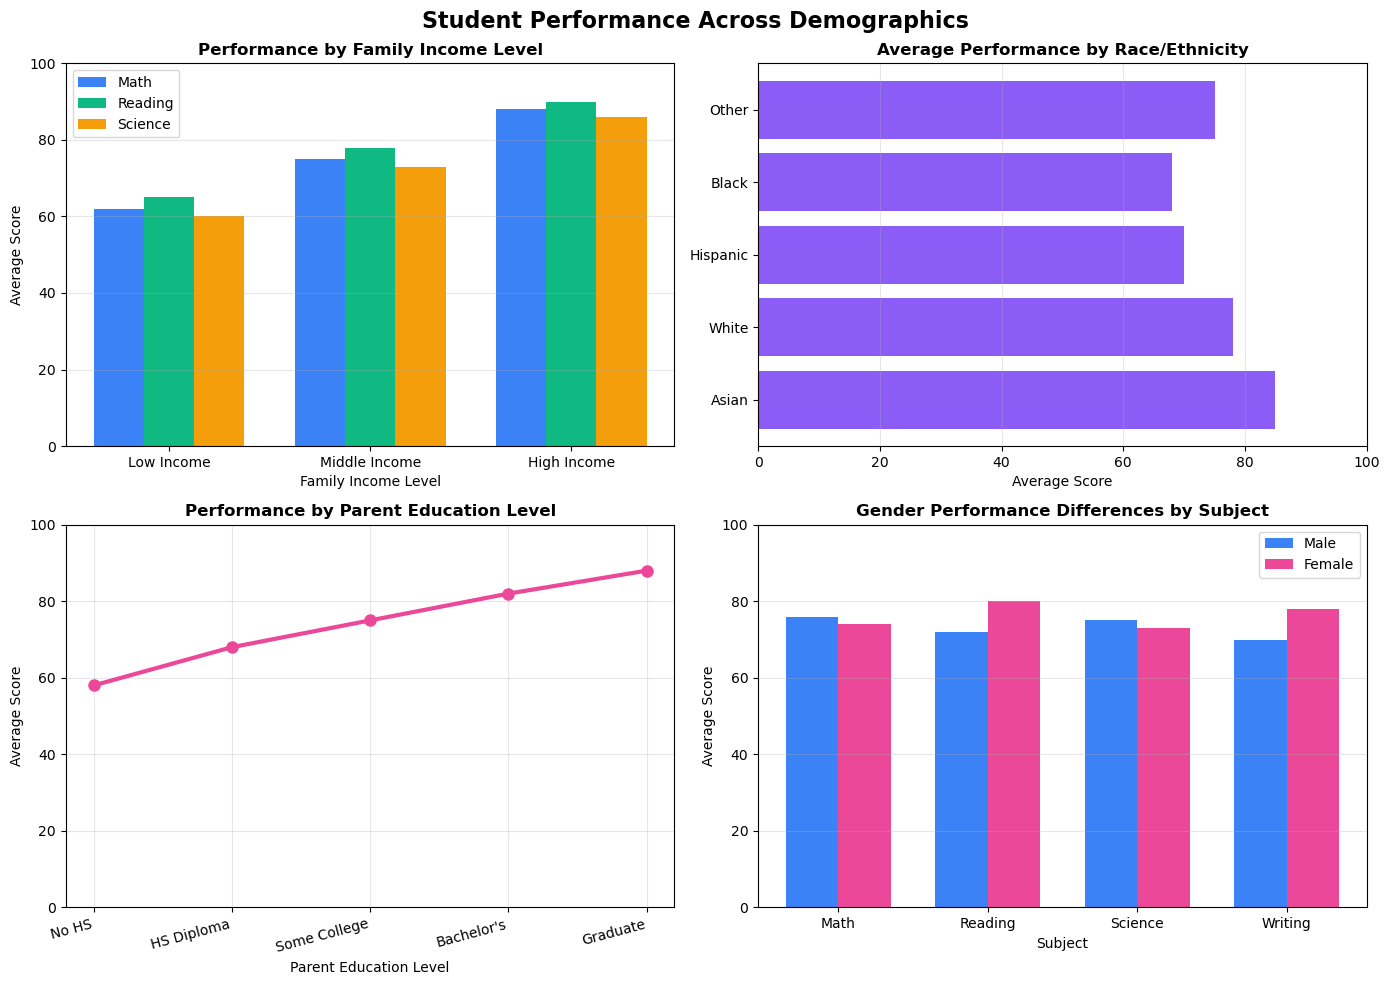

In [24]:
# the AI generated visualization based on prompt
import matplotlib.pyplot as plt
import numpy as np

# Simulated student performance data
performance_by_income = {
    'income': ['Low Income', 'Middle Income', 'High Income'],
    'math': [62, 75, 88],
    'reading': [65, 78, 90],
    'science': [60, 73, 86]
}

performance_by_race = {
    'group': ['Asian', 'White', 'Hispanic', 'Black', 'Other'],
    'avgScore': [85, 78, 70, 68, 75]
}

performance_by_parent_ed = {
    'education': ['No HS', 'HS Diploma', 'Some College', "Bachelor's", 'Graduate'],
    'score': [58, 68, 75, 82, 88]
}

gender_performance = {
    'subject': ['Math', 'Reading', 'Science', 'Writing'],
    'male': [76, 72, 75, 70],
    'female': [74, 80, 73, 78]
}

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Student Performance Across Demographics', fontsize=16, fontweight='bold')

# Chart 1: Performance by Income Level
ax1 = axes[0, 0]
x = np.arange(len(performance_by_income['income']))
width = 0.25

bars1 = ax1.bar(x - width, performance_by_income['math'], width, label='Math', color='#3b82f6')
bars2 = ax1.bar(x, performance_by_income['reading'], width, label='Reading', color='#10b981')
bars3 = ax1.bar(x + width, performance_by_income['science'], width, label='Science', color='#f59e0b')

ax1.set_xlabel('Family Income Level')
ax1.set_ylabel('Average Score')
ax1.set_title('Performance by Family Income Level', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(performance_by_income['income'])
ax1.set_ylim(0, 100)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Performance by Race/Ethnicity (Horizontal Bar)
ax2 = axes[0, 1]
y_pos = np.arange(len(performance_by_race['group']))
ax2.barh(y_pos, performance_by_race['avgScore'], color='#8b5cf6')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(performance_by_race['group'])
ax2.set_xlabel('Average Score')
ax2.set_title('Average Performance by Race/Ethnicity', fontweight='bold')
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3)

# Chart 3: Performance by Parent Education (Line Chart)
ax3 = axes[1, 0]
ax3.plot(performance_by_parent_ed['education'], performance_by_parent_ed['score'], 
         marker='o', linewidth=3, markersize=8, color='#ec4899')
ax3.set_xlabel('Parent Education Level')
ax3.set_ylabel('Average Score')
ax3.set_title('Performance by Parent Education Level', fontweight='bold')
ax3.set_ylim(0, 100)
ax3.grid(alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15, ha='right')

# Chart 4: Gender Performance by Subject
ax4 = axes[1, 1]
x = np.arange(len(gender_performance['subject']))
width = 0.35

bars1 = ax4.bar(x - width/2, gender_performance['male'], width, label='Male', color='#3b82f6')
bars2 = ax4.bar(x + width/2, gender_performance['female'], width, label='Female', color='#ec4899')

ax4.set_xlabel('Subject')
ax4.set_ylabel('Average Score')
ax4.set_title('Gender Performance Differences by Subject', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(gender_performance['subject'])
ax4.set_ylim(0, 100)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



**Audit**

Since there is no actual data being given to the AI they can either make everything up or find online data which can still be misleading if the data is not accurate. There is no way to tell if the data/what is shown is correct/accurate or not and some people might blindfly trust it because it looks normal. There needs to be a disclaimer highlighting how the AI generated this by themslevs and made assumptions and the data they gathered cna be fake or inaccurate. 

#### Section 4 — Guardrails: How to Use AI Responsibly 

##### A practical checklist
**Safe uses (usually)**
- Boilerplate code scaffolding and syntax help
- Brainstorming alternative encodings
- Drafting captions, tooltips, and accessibility text (with review)
- Summarizing chart limitations

**Risky uses (require strong human judgment)**
- Choosing encodings without domain/task context
- Interpreting patterns as “insights”
- Working with sensitive or high-stakes data
- Making ethical calls about grouping, labeling, or framing

> **Rule of thumb:** AI accelerates *execution*, not *judgment*.


##### Reflection prompts
1. What part of your viz workflow did AI help most today?
2. What failure mode surprised you?
3. What guardrail will you adopt immediately in your own work?
4. Ask AI to give you some suggestions about making visualization using AI. 


I would say AI helps me the most with syntax errors that I'm not familiar with or not really doing correctly. And a lot of times when I am debugging I ask AI for help because I don't really know whats going on and how to fix it.

What I'm most supprised about AI is that sometimes I catch the AI being wrong or incorrect and I ask it to explain and tell them why its wrong or what I think it still thinks its correct until I run the code or prove that mine is correct. I can't argue with it and sometimes when I try to correct it it changes my mind instead. 

I will always double check the stuff AI gives me to see if its it correct and accurate. I have also learned that its better sometimes ot be very specific in the tasks and break the part into even smaller parts for AI to better digest and comprehend. 

**AI Generated Tips** 
* Describe the "Story," not just the data: Instead of saying "Make a bar chart of this CSV," say "I want to show that sales dropped specifically in Q3 because of supply chain issues. Suggest a visualization that highlights that dip."
* Use AI for "Chart Logic": Ask, "I have categorical data with 50 items. A bar chart is too crowded. What are three alternative ways to visualize this for a mobile screen?"
* The "Rubber Duck" Method: Explain your complex data structure to the AI. If the AI can summarize it back to you accurately, it understands the context well enough to help you code the visual.
